### Praktikum Kecerdasan Buatan K-Means
Nama            : Laura Aurelia  
NIM             : 42324027  
Program Studi   : D3 Teknologi Informasi

K-Means Clustering digunakan untuk mengelompokkan data ke dalam beberapa klaster berdasarkan kesamaan karakteristik. Analisis ini menggunakan dataset Mall Customers, yang memuat berbagai informasi pelanggan. Sebagai langkah awal, proses klasterisasi akan difokuskan pada dua fitur utama, yaitu Annual Income dan Spending Score, untuk menyederhanakan pemahaman serta mempermudah visualisasi klaster. Pendekatan ini memungkinkan interpretasi hasil yang lebih intuitif sebelum melibatkan fitur lainnya.

Penjelasan singkat mengenai K-Means: algoritma ini membagi data menjadi k klaster, dan setiap klaster diwakili oleh sebuah titik pusat yang disebut centroid. Cara kerjanya adalah menentukan k centroid awal, memasukkan setiap data ke klaster dengan centroid terdekat berdasarkan jarak Euclidean, menghitung ulang posisi centroid sebagai rata-rata anggota klasternya, lalu mengulang dua langkah terakhir sampai posisi centroid tidak lagi berubah. K-Means termasuk unsupervised learning karena data tidak memiliki label kelas.

In [1]:
import pandas as pd
df = pd.read_csv('/content/Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Pada cell ini library pandas diimpor dengan alias pd, kemudian file Mall_Customers.csv dibaca ke dalam DataFrame bernama df. Path /content digunakan karena file diunggah ke Google Colab, sehingga path perlu disesuaikan apabila praktikum dijalankan di lingkungan lain. Perintah df.head() menampilkan lima baris pertama untuk memastikan data terbaca dengan benar.

Dari hasil tersebut terlihat dataset memiliki lima kolom, yaitu CustomerID sebagai nomor identitas pelanggan, Genre sebagai jenis kelamin, Age sebagai usia, Annual Income (k$) sebagai pendapatan tahunan dalam ribuan dolar, dan Spending Score (1-100) sebagai skor belanja pelanggan dengan skala 1 sampai 100.

In [2]:
# cek missing values
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Sebelum data digunakan, perlu dipastikan tidak ada nilai yang hilang (missing values). Perintah df.isnull().sum() menghitung jumlah nilai kosong pada setiap kolom. Hasilnya adalah 0 untuk seluruh kolom, yaitu CustomerID, Genre, Age, Annual Income (k$), dan Spending Score (1-100). Artinya data lengkap dan tidak memerlukan penanganan nilai yang hilang, seperti penghapusan baris atau pengisian nilai.

In [3]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Perintah df.describe() menampilkan ringkasan statistik untuk kolom numerik, yaitu jumlah data (count), rata-rata (mean), simpangan baku (std), nilai minimum, kuartil pertama (25%), median (50%), kuartil ketiga (75%), dan nilai maksimum.

Jumlah data pada setiap kolom adalah 200, sesuai dengan hasil pengecekan missing values sebelumnya. Rata-rata usia pelanggan adalah 38,85 tahun dengan rentang 18 sampai 70 tahun. Rata-rata pendapatan tahunan adalah 60,56 ribu dolar dengan rentang 15 sampai 137 ribu dolar, median 61,5, dan simpangan baku 26,26. Rata-rata Spending Score adalah 50,2 dengan rentang 1 sampai 99 dan simpangan baku 25,82. Statistik pada kolom CustomerID tidak perlu ditafsirkan karena kolom tersebut hanya berisi nomor urut pelanggan.

In [4]:
dataset = df.iloc[:,3:]
dataset.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


Perintah df.iloc[:,3:] memilih seluruh baris dan kolom mulai dari indeks 3 sampai kolom terakhir. Indeks kolom dimulai dari 0, yaitu CustomerID (0), Genre (1), Age (2), Annual Income (k$) (3), dan Spending Score (1-100) (4). Dengan demikian dataset hanya berisi dua kolom, yaitu Annual Income dan Spending Score, yang menjadi fitur untuk klasterisasi tahap pertama.

In [5]:
x = df.iloc[:, 3]
y = df.iloc[:, 4]

Kolom indeks 3 (Annual Income) disimpan pada variabel x dan kolom indeks 4 (Spending Score) disimpan pada variabel y. Kedua variabel ini digunakan sebagai sumbu horizontal dan sumbu vertikal pada diagram sebar.

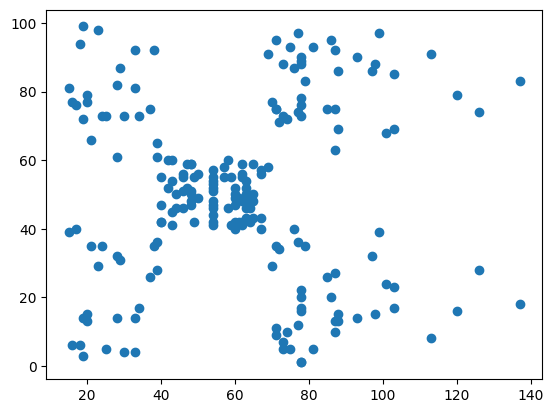

In [6]:
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.show()

Library matplotlib.pyplot diimpor untuk membuat grafik, lalu plt.scatter(x, y) membuat diagram sebar dengan Annual Income pada sumbu horizontal dan Spending Score pada sumbu vertikal. Setiap titik mewakili satu pelanggan.

Pada diagram terlihat adanya pola kelompok. Terdapat satu kelompok padat di bagian tengah, yaitu pelanggan dengan pendapatan sedang dan skor belanja sedang. Selain itu terdapat empat kelompok di sudut-sudut diagram, yaitu pendapatan rendah dengan skor rendah, pendapatan rendah dengan skor tinggi, pendapatan tinggi dengan skor rendah, serta pendapatan tinggi dengan skor tinggi. Dari pola ini diperkirakan jumlah klaster adalah lima, dan perkiraan tersebut diperiksa menggunakan Elbow Method pada langkah berikutnya.

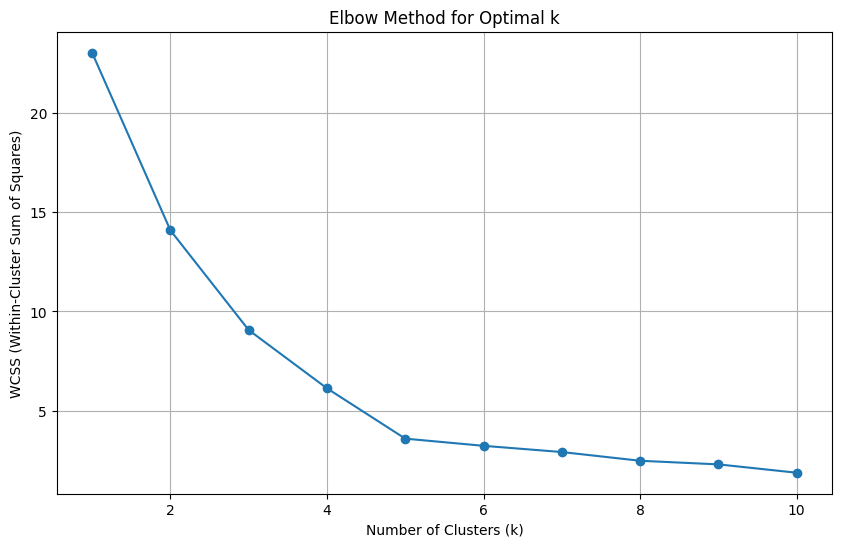

In [7]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Scaling data dengan MinMaxScaler
scaler = MinMaxScaler()

# Mengambil kolom X (index 3) dan Y (index 4) dari DataFrame
X = pd.DataFrame({'Annual Income (k$)': x, 'Spending Score (1-100)': y})

X_scaled = scaler.fit_transform(X)

# Menentukan jumlah klaster optimal menggunakan Elbow Method
wcss = []
for i in range(1, 11):  # Coba k dari 1 sampai 10
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Membuat plot Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

Cell ini bertujuan menentukan jumlah klaster yang optimal dengan Elbow Method. Langkah-langkahnya adalah sebagai berikut.

Pertama, kolom Annual Income dan Spending Score digabung menjadi DataFrame X. Kedua, data diskalakan menggunakan MinMaxScaler, yang mengubah setiap fitur ke rentang 0 sampai 1 dengan rumus (nilai - minimum) / (maksimum - minimum). Penskalaan diperlukan karena K-Means bekerja berdasarkan jarak, sehingga fitur dengan rentang nilai yang besar akan lebih mendominasi apabila tidak diseragamkan. Hasil penskalaan disimpan pada X_scaled.

Ketiga, dilakukan perulangan untuk k dari 1 sampai 10. Pada setiap perulangan, K-Means dilatih dengan jumlah klaster sebanyak i, kemudian nilai WCSS (Within-Cluster Sum of Squares) disimpan. WCSS adalah jumlah kuadrat jarak setiap titik ke centroid klasternya, dan pada scikit-learn nilainya tersedia pada atribut inertia_. Parameter random_state=42 dipakai agar hasilnya dapat diulang dengan nilai yang sama.

Keempat, nilai WCSS pada tiap k digambarkan dalam grafik. Nilai WCSS selalu menurun seiring bertambahnya k, karena semakin banyak klaster maka jarak titik ke centroid semakin kecil. Yang dicari adalah titik siku (elbow), yaitu titik setelah penurunan WCSS tidak lagi tajam.

Pada grafik, WCSS turun tajam dari sekitar 23 pada k=1 menjadi sekitar 14 pada k=2, sekitar 9 pada k=3, sekitar 6 pada k=4, dan sekitar 3,6 pada k=5. Setelah k=5 penurunannya menjadi landai. Dengan demikian titik siku berada pada k=5, sehingga jumlah klaster optimal untuk dua fitur ini adalah 5. Hasil ini sesuai dengan perkiraan awal dari diagram sebar.

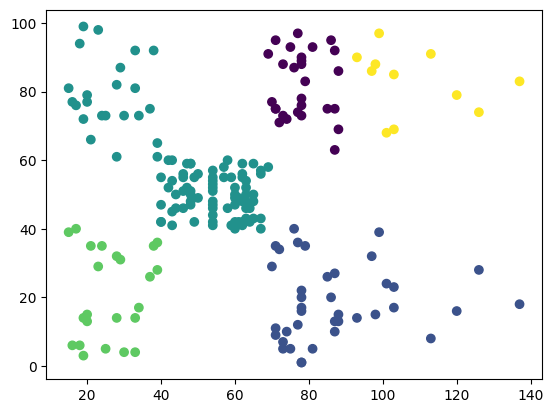

In [8]:
# dari elbow method, nilai k optimal untuk data ini adalah 5
kmeans = KMeans(n_clusters=5)
kmeans.fit(X)

# Plot hasil klaster
plt.scatter(x, y, c=kmeans.labels_)
plt.show()

Berdasarkan Elbow Method, K-Means dibentuk dengan n_clusters=5 kemudian dilatih menggunakan fit(X). Atribut kmeans.labels_ berisi nomor klaster (0 sampai 4) untuk setiap pelanggan, dan nomor tersebut dipakai sebagai warna titik pada diagram sebar melalui parameter c.

Dua hal perlu diperhatikan pada cell ini. Pertama, model dilatih menggunakan X, yaitu data asli yang belum diskalakan, bukan X_scaled. Pada kasus ini hasilnya tetap baik karena kedua fitur memiliki rentang yang mirip (15 sampai 137 untuk pendapatan dan 1 sampai 99 untuk skor belanja). Kedua, parameter random_state tidak diisi sehingga posisi centroid awal dipilih secara acak. Akibatnya nomor dan warna tiap klaster dapat berbeda setiap kali cell dijalankan, namun pembagian kelompoknya pada dasarnya sama.

Hasil klasterisasi menunjukkan lima kelompok yang terpisah dengan jelas, yaitu kelompok pendapatan sedang dengan skor belanja sedang (kelompok terbesar di tengah), kelompok pendapatan tinggi dengan skor belanja tinggi, kelompok pendapatan tinggi dengan skor belanja rendah, kelompok pendapatan rendah dengan skor belanja tinggi, dan kelompok pendapatan rendah dengan skor belanja rendah. Pembagian ini sesuai dengan pola yang terlihat pada diagram sebar awal. Dari sudut pandang bisnis, kelima kelompok tersebut menjadi segmen pelanggan yang dapat diberi strategi pemasaran berbeda.

Selanjutnya klasterisasi dilakukan dengan menggunakan tiga fitur utama, yaitu Age, Annual Income, dan Spending Score.

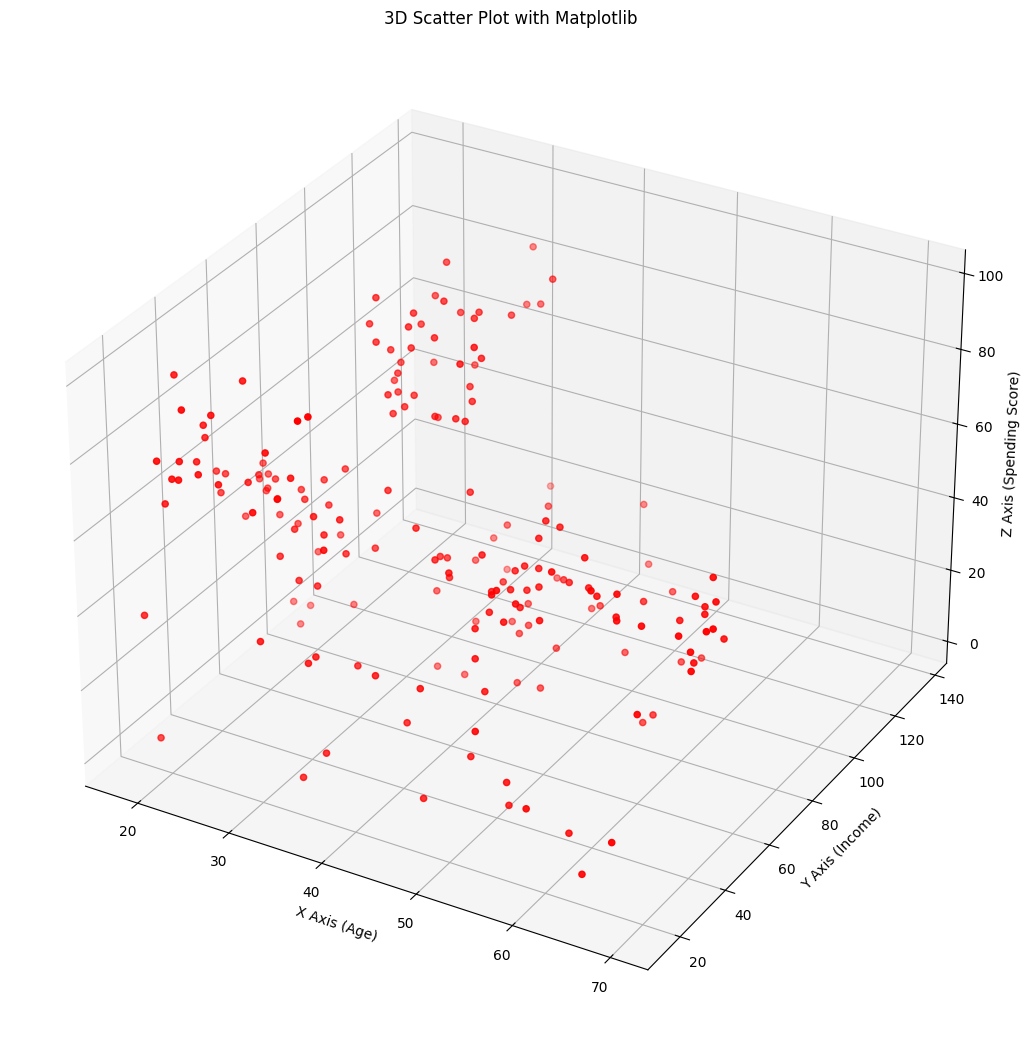

In [9]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Data Age, Annual Income, dan Spending Score
x = df.iloc[:, 2]
y = df.iloc[:, 3]
z = df.iloc[:, 4]

# Membuat plot 3D
fig = plt.figure(figsize=(13, 13))
ax = fig.add_subplot(111, projection='3d')

# Plot data
ax.scatter(x, y, z, c='red', marker='o')

# Label sumbu
ax.set_xlabel('X Axis (Age)')
ax.set_ylabel('Y Axis (Income)')
ax.set_zlabel('Z Axis (Spending Score)')

plt.title('3D Scatter Plot with Matplotlib')
plt.show()

Pada tahap ini fitur Age ditambahkan sehingga data memiliki tiga dimensi. Variabel x, y, dan z diisi ulang, yaitu x berisi Age (indeks 2), y berisi Annual Income (indeks 3), dan z berisi Spending Score (indeks 4). Karena itu nilai x dan y di sini berbeda dari nilai x dan y pada tahap dua fitur.

Library Axes3D dan numpy diimpor, kemudian dibuat grafik berukuran 13 x 13 dengan proyeksi tiga dimensi (projection='3d'). Fungsi ax.scatter(x, y, z) menggambar setiap pelanggan sebagai satu titik berwarna merah, lalu set_xlabel, set_ylabel, dan set_zlabel memberi nama pada ketiga sumbu.

Pada plot ini seluruh titik masih berwarna sama sehingga belum menunjukkan pembagian kelompok. Sebaran titik dalam tiga dimensi juga tidak sejelas pada dua dimensi, sehingga perlu dilakukan penentuan jumlah klaster kembali.

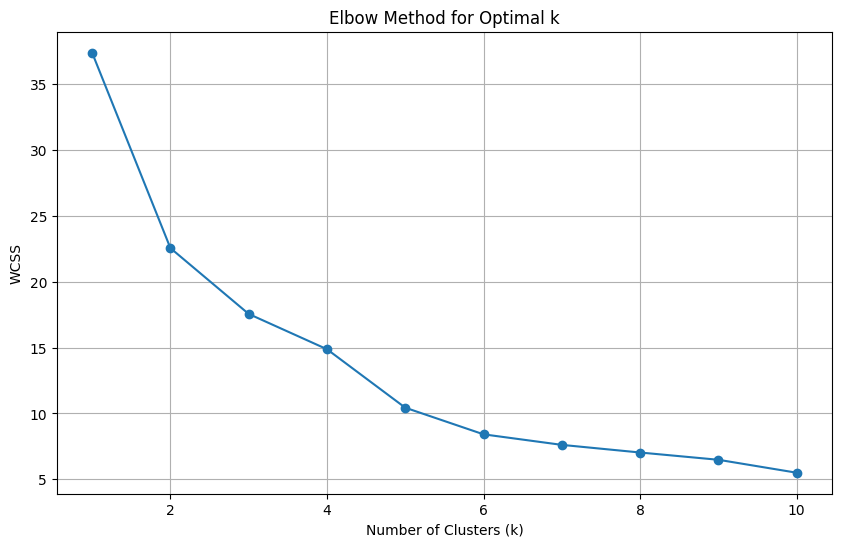

In [10]:
# Menggabungkan data X, Y, Z menjadi array untuk clustering
X = np.array(list(zip(x, y, z)))

# Scaling data dengan MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Menentukan jumlah klaster optimal dengan Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Visualisasi Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

Pada cell ini ketiga variabel digabung dengan zip menjadi pasangan (Age, Income, Spending Score) untuk tiap pelanggan, kemudian diubah menjadi array numpy X berukuran 200 baris dan 3 kolom. Data kemudian diskalakan dengan MinMaxScaler menjadi X_scaled, dan proses Elbow Method dilakukan dengan cara yang sama seperti pada dua fitur.

Pada grafik, WCSS turun dari sekitar 37 pada k=1 menjadi sekitar 22,6 pada k=2, sekitar 17,6 pada k=3, sekitar 15 pada k=4, sekitar 10,4 pada k=5, dan sekitar 8,4 pada k=6. Setelah k=6 penurunannya melandai, yaitu sekitar 7,6 pada k=7 dan seterusnya turun perlahan. Siku pada grafik ini tidak setegas pada dua fitur karena penurunan masih terlihat dari k=5 ke k=6. Berdasarkan grafik tersebut dipilih k=6 sebagai jumlah klaster, sebab setelah titik ini penambahan klaster tidak lagi memberi penurunan WCSS yang besar.

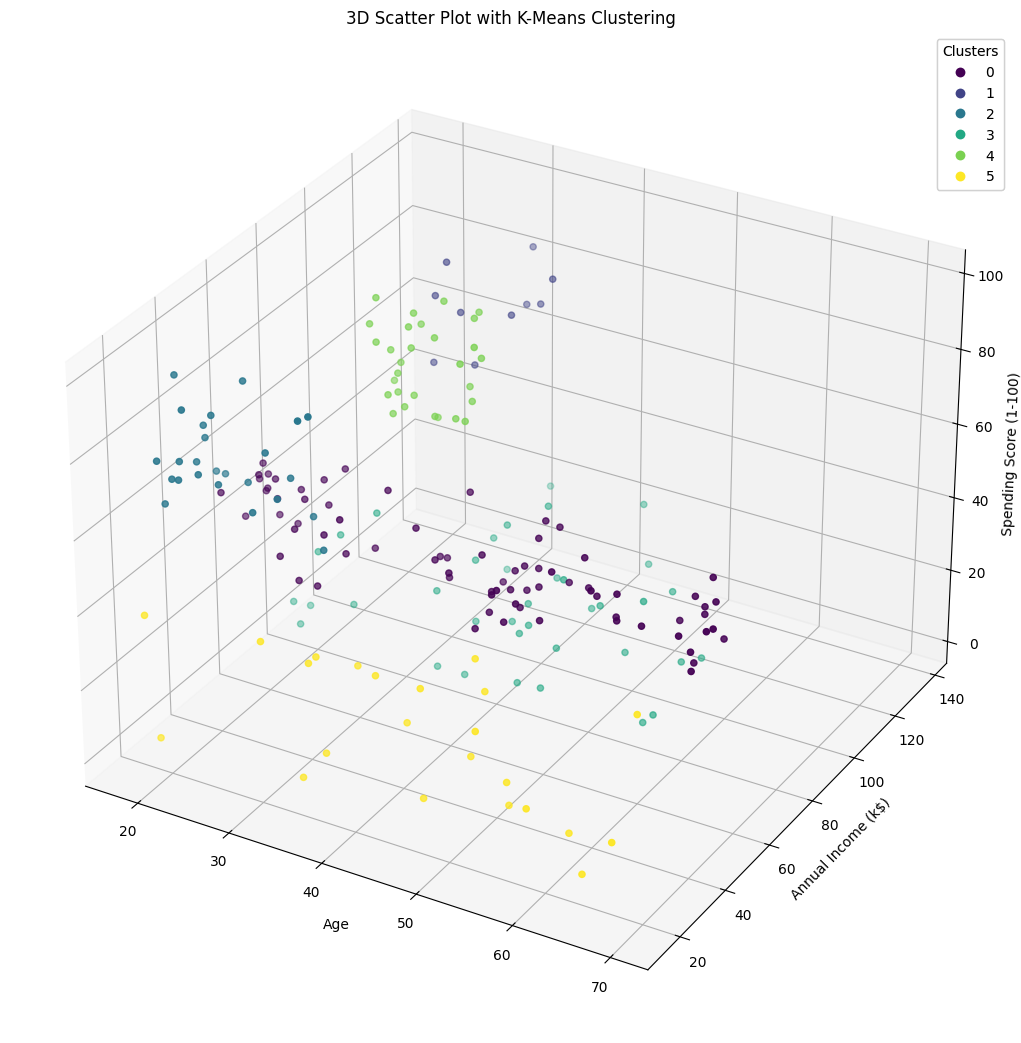

In [11]:
# Pilih k optimal setelah melihat Elbow
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X)

# Menambahkan hasil klaster ke DataFrame
df['Cluster'] = clusters


# Visualisasi 3D Hasil K-Means

# Plot data dengan warna berdasarkan klaster
fig = plt.figure(figsize=(13, 13))
ax = fig.add_subplot(111, projection='3d')

# Plot setiap titik dengan warna sesuai klaster
scatter = ax.scatter(x, y, z, c=clusters, cmap='viridis', marker='o')

# Label sumbu
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')

# Menampilkan legenda klaster
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)

plt.title('3D Scatter Plot with K-Means Clustering')
plt.show()

Setelah k=6 dipilih, K-Means dibentuk dengan n_clusters=6 dan random_state=42. Fungsi fit_predict melatih model sekaligus mengembalikan nomor klaster (0 sampai 5) untuk setiap pelanggan, yang disimpan pada variabel clusters. Nomor tersebut kemudian ditambahkan ke DataFrame sebagai kolom Cluster, sehingga setiap pelanggan memiliki keterangan klasternya dan data dapat dianalisis lebih lanjut per klaster.

Visualisasi dibuat dalam plot tiga dimensi dengan sumbu Age, Annual Income, dan Spending Score. Warna titik ditentukan oleh nomor klaster menggunakan peta warna viridis, dan legenda dibuat dari scatter.legend_elements() sehingga setiap warna dapat dikenali nomor klasternya. Perintah ax.add_artist(legend1) memastikan legenda tetap tampil pada grafik.

Hasilnya, pelanggan terbagi menjadi enam kelompok yang berbeda warna. Dibandingkan dengan klasterisasi dua fitur yang menghasilkan lima kelompok, penambahan fitur Age membuat pembagian lebih rinci, sehingga pelanggan dengan pendapatan dan skor belanja yang mirip dapat dibedakan lagi berdasarkan usianya.

Catatan: pada cell ini model dilatih menggunakan X, yaitu data asli yang belum diskalakan, sedangkan penentuan k pada Elbow Method memakai X_scaled. Pada data yang belum diskalakan, fitur dengan rentang nilai lebih besar, yaitu Annual Income (15 sampai 137), memiliki pengaruh yang lebih besar terhadap jarak dibandingkan Age (18 sampai 70) dan Spending Score (1 sampai 99). Karena itu batas antar klaster pada plot ini lebih dipengaruhi oleh nilai asli dari ketiga fitur tersebut.